In [1]:
import os
import torch
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.distributions.star_gaussians.multi_inverse_linear_norm_gaussian import MultiInverseLinearStarNormGaussianDistribution
from src.distributions.diagonal_gaussian import DiagonalGaussian
from src.distributions.product import ProductDistribution

ImportError: cannot import name 'DiagonalGaussian' from 'src.distributions.diagonal_gaussian' (/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/src/distributions/diagonal_gaussian.py)

In [ ]:
num_radials = 2
distribution = ProductDistribution(
    [MultiInverseLinearStarNormGaussianDistribution(2, num_radials=num_radials), 
     DiagonalGaussian(1, sigma=0.05)
     ])

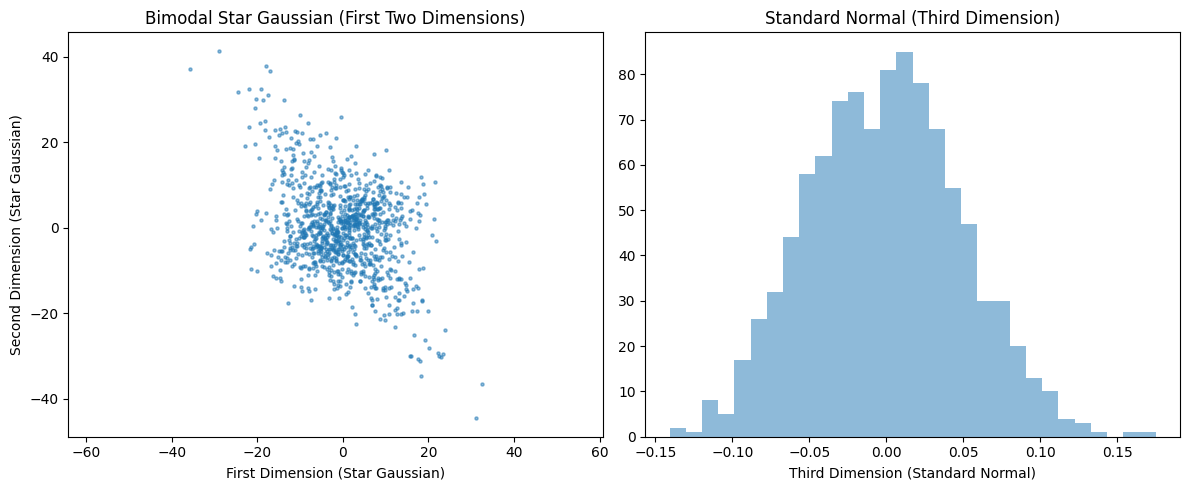

In [ ]:
# sample from distribution and plot first two dimensions (the star gaussian part) in 2D and third dimension (the standard normal part) in a histogram
num_samples = 1000
with torch.no_grad():
    samples = distribution.sample(num_samples)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(samples[:, 0].numpy(), samples[:, 1].numpy(), s=5, alpha=0.5)
plt.xlabel("First Dimension (Star Gaussian)")
plt.ylabel("Second Dimension (Star Gaussian)")
plt.axis('equal')
plt.title("Bimodal Star Gaussian (First Two Dimensions)")
plt.subplot(1, 2, 2)
plt.hist(samples[:, 2].numpy(), bins=30, alpha=0.5)
plt.xlabel("Third Dimension (Standard Normal)")
plt.title("Standard Normal (Third Dimension)")
plt.tight_layout()
plt.show()